Есептер

✅ 1-БӨЛІМ. KNN — ТАПСЫРМАЛАР
🔹 Тапсырма 1 (Beginner)
Мақсаты: KNN классификациясын үйрену
Iris датасетін жүкте


Деректі 80% / 20% бөліп бөл


k=3 және k=7 үшін:


модель құр


accuracy есепте


Нәтижені салыстыр


✅ Тапсыру керек:
Accuracy мәндері


Қай k жақсы екенін қорытындылау



🔹 Тапсырма 2 (Intermediate)
KNN үшін feature scaling (StandardScaler) қолдан


Масштабтауға дейін және кейін accuracy салыстыр


Қайсысы жақсы жұмыс істегенін түсіндір



🔹 Тапсырма 3 (Advanced)
K мәнін [1–20] аралығында өзгертіп

Әр k үшін accuracy есептеп

График сал (k vs accuracy)

Оптималды K таңда

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_20newsgroups

from sklearn.model_selection import train_test_split, GridSearchCV


from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering


In [2]:
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for k in [3,7]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(k, accuracy_score(y_test, y_pred))


3 1.0
7 0.9666666666666667


In [3]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

for scaled in [False, True]:
    Xt = X_train_s if scaled else X_train
    Xv = X_test_s if scaled else X_test
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(Xt, y_train)
    print(scaled, accuracy_score(y_test, model.predict(Xv)))


False 1.0
True 1.0


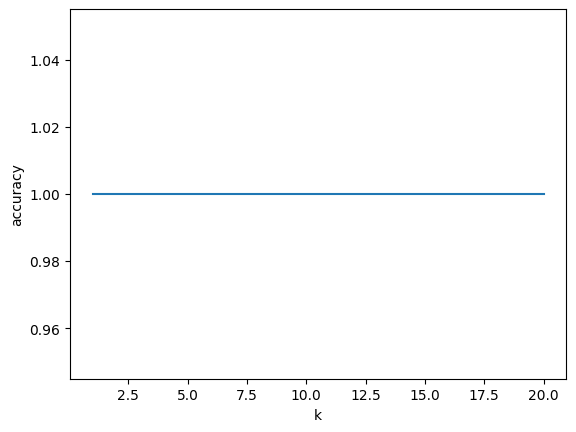

In [4]:
accs = []
ks = range(1,21)
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    accs.append(accuracy_score(y_test, model.predict(X_test_s)))

plt.plot(ks, accs)
plt.xlabel("k")
plt.ylabel("accuracy")
plt.show()


2-БӨЛІМ. SVM


✅ 2-БӨЛІМ. SVM — ТАПСЫРМАЛАР
🔹 Тапсырма 4 (Beginner)
Iris датасетіне:


linear


rbf


poly kernel қолданып көр


Accuracy салыстыр


✅ Қорытынды жаса:
Қай kernel жақсы?


Неге?


🔹 Тапсырма 5 (Intermediate)
C параметрін өзгертіңіз: 0.1, 1, 10


Әрқайсысына accuracy есептеңіз


Overfitting бар-жоғын талдаңыз



🔹 Тапсырма 6 (Advanced)
GridSearchCV арқылы:


C


gamma
 параметрлерін оптимизациялаңыз


Ең үздік модельдің accuracy шығарыңыз



In [5]:
for kernel in ["linear","rbf","poly"]:
    model = SVC(kernel=kernel)
    model.fit(X_train_s, y_train)
    print(kernel, accuracy_score(y_test, model.predict(X_test_s)))


linear 0.9666666666666667
rbf 1.0
poly 0.9666666666666667


In [6]:
for C in [0.1,1,10]:
    model = SVC(C=C)
    model.fit(X_train_s, y_train)
    print(C, accuracy_score(y_test, model.predict(X_test_s)))


0.1 0.9666666666666667
1 1.0
10 0.9666666666666667


In [7]:
params = {"C":[0.1,1,10],"gamma":[0.01,0.1,1]}
gs = GridSearchCV(SVC(), params, cv=5)
gs.fit(X_train_s, y_train)
print(gs.best_params_, accuracy_score(y_test, gs.best_estimator_.predict(X_test_s)))


{'C': 1, 'gamma': 0.1} 1.0



✅ 3-БӨЛІМ. NAIVE BAYES — ТАПСЫРМАЛАР
🔹 Тапсырма 7 (Beginner)
GaussianNB моделін үйрет


Confusion Matrix құр


Accuracy + Precision + Recall есепте



🔹 Тапсырма 8 (Intermediate)
20 Newsgroups датасетін жүкте


Мәтінді TF-IDF арқылы векторизацияла


MultinomialNB қолдан


Spam / Not Spam классификация жаса



🔹 Тапсырма 9 (Advanced)
Naive Bayes-ті:


KNN


Decision Tree
 модельдерімен салыстыр


Қайсысы мәтінге жақсы екенін дәлелде



In [8]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred, average="macro"))
print(recall_score(y_test, y_pred, average="macro"))


[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
1.0
1.0
1.0


In [9]:
data = fetch_20newsgroups(subset="train", categories=["sci.space","rec.autos"])
vectorizer = TfidfVectorizer(max_features=5000)
X_text = vectorizer.fit_transform(data.data)
y_text = data.target

Xtr, Xte, ytr, yte = train_test_split(X_text, y_text, test_size=0.2, random_state=42)

nb = MultinomialNB()
nb.fit(Xtr, ytr)
print(accuracy_score(yte, nb.predict(Xte)))


0.9915966386554622


In [10]:
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()

knn.fit(Xtr, ytr)
dt.fit(Xtr, ytr)

print("NB", accuracy_score(yte, nb.predict(Xte)))
print("KNN", accuracy_score(yte, knn.predict(Xte)))
print("DT", accuracy_score(yte, dt.predict(Xte)))


NB 0.9915966386554622
KNN 0.9873949579831933
DT 0.9495798319327731


✅ 4-БӨЛІМ. DECISION TREE — ТАПСЫРМАЛАР
🔹 Тапсырма 10 (Beginner)
Decision Tree үйрет


max_depth = 2, 4, 6 үшін accuracy есепте


Overfitting қай кезде шыққанын анықта



🔹 Тапсырма 11 (Intermediate)
Ағашты визуализацияла:


from sklearn.tree import plot_tree

Қай feature ең маңызды екенін анықта



🔹 Тапсырма 12 (Advanced)
Decision Tree vs Random Forest салыстыр


Қайсысы:


дәлірек


тұрақты
 екенін дәлелде


In [11]:
for d in [2,4,6]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)
    print(d, accuracy_score(y_test, dt.predict(X_test)))


2 0.9666666666666667
4 1.0
6 1.0


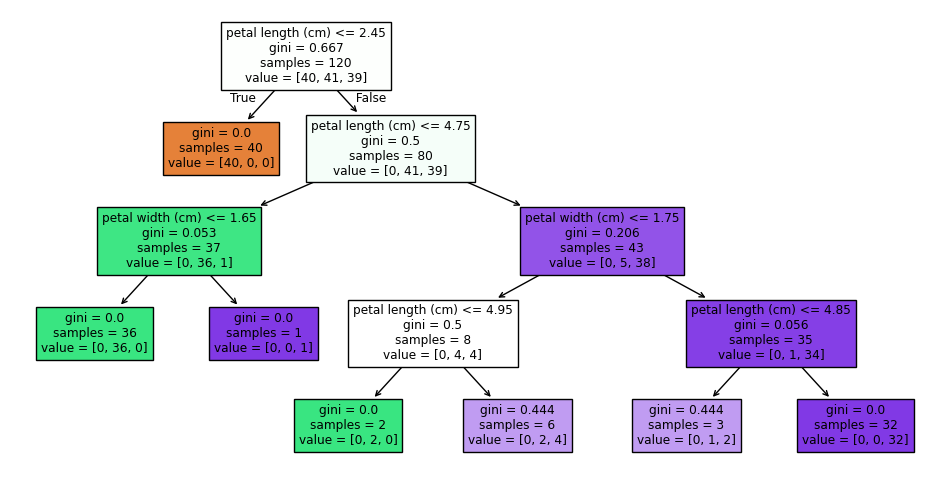

In [12]:
dt = DecisionTreeClassifier(max_depth=4)
dt.fit(X_train, y_train)
plt.figure(figsize=(12,6))
plot_tree(dt, feature_names=iris.feature_names, filled=True)
plt.show()


In [13]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

print("DT", accuracy_score(y_test, dt.predict(X_test)))
print("RF", accuracy_score(y_test, rf.predict(X_test)))


DT 1.0
RF 1.0




✅ 5-БӨЛІМ. КЛАСТЕРЛЕУ — ТАПСЫРМАЛАР
🔹 Тапсырма 13 (Beginner)
K-Means арқылы 3 кластер құр


PCA арқылы 2D визуализация жаса


Әр кластердің центрін көрсет



🔹 Тапсырма 14 (Intermediate)
k = 2 → 10 дейін өзгертіп


Elbow Method графигін сал


Оптималды кластер санын таңда



🔹 Тапсырма 15 (Advanced)
K-Means, DBSCAN, Hierarchical салыстыр


Silhouette Score есепте


Қай алгоритм шулы дерекке жақсы екенін түсіндір




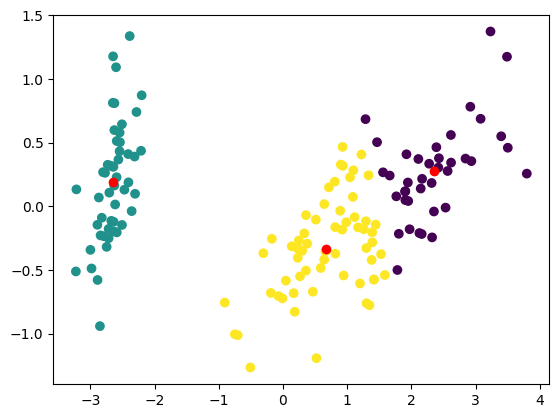

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

plt.scatter(X2[:,0], X2[:,1], c=labels)
plt.scatter(pca.transform(kmeans.cluster_centers_)[:,0],
            pca.transform(kmeans.cluster_centers_)[:,1],
            c="red")
plt.show()


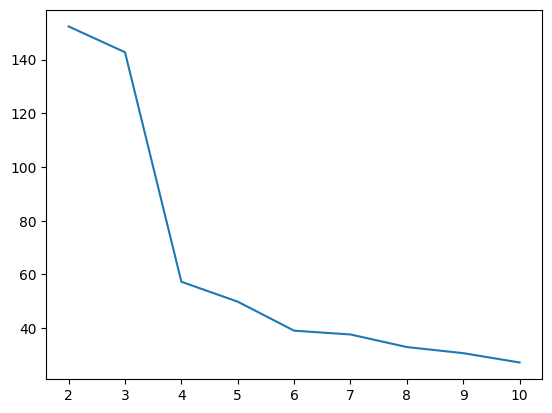

In [15]:
inertia = []
for k in range(2,11):
    km = KMeans(n_clusters=k)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(2,11), inertia)
plt.show()


In [16]:
kmeans = KMeans(n_clusters=3).fit(X)
db = DBSCAN(eps=0.5).fit(X)
hc = AgglomerativeClustering(n_clusters=3).fit(X)

print("KMeans", silhouette_score(X, kmeans.labels_))
print("DBSCAN", silhouette_score(X, db.labels_))
print("Hierarchical", silhouette_score(X, hc.labels_))


KMeans 0.5511916046195919
DBSCAN 0.48603419703456857
Hierarchical 0.5543236611296419



✅ 6-БӨЛІМ. ЖЕКЕ ЖОБА (MINI-PROJECT)
🔥 Финалдық тапсырма
Студент өз бетінше:
Өз датасетін таңдайды (Kaggle, CSV)


Кемінде 3 модельді қолданады:


KNN


SVM


Decision Tree


Accuracy, Confusion Matrix есептейді


Ең жақсы модельді таңдайды


ҚОРҒАУ:


Неге осы модель?


Неге басқалары емес?

help me with these tasks , pls without comments 


In [19]:
models = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "DT": DecisionTreeClassifier()
}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    print(name, accuracy_score(y_test, pred),'\n')
    print(confusion_matrix(y_test, pred),'\n')


KNN 1.0 

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]] 

SVM 1.0 

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]] 

DT 1.0 

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]] 

